In [1]:
from engine import BirdsEye
from strategies.range_short_strangle import RangeShortStrangle

if __name__ == "__main__":
    be = BirdsEye(
        data_dir          = "/mnt/INTERNAL_DATA/INTERN_DATA/OPRA_DATA_1SEC/0DTE/SPY",
        strategy_cls      = RangeShortStrangle,
        index             = "SPY",
        lot_size          = 100,
        starting_cash     = 1_000_000.0,
        margin_per_lot    = 10000.0,
        strategy_kwargs   = {"lots": 10, "max_lots": 10},
        cost_kwargs       = {"txn_cost_per_lot": 0.85},
        n_workers         = 20,
        collect_perseclog = True,
    )
    
    res = be.run()

In [2]:
import matplotlib.pyplot as plt

DAY = "20240208"

# ---- 1. per-day summary table ----
print("=== per-day summary ===")
display(res.summary)


=== per-day summary ===


,fills,gross($),costs($),net($)
day,,,,
20240102,132,-260.0,324.0,-584.0
20240104,136,103.0,378.0,-275.0
20240105,110,-490.5,270.5,-761.0
20240109,136,52.0,378.0,-326.0
20240110,136,-31.5,379.5,-411.0
...,...,...,...,...
20250804,136,383.0,378.0,5.0
20250806,136,239.0,380.0,-141.0
20250807,44,-635.0,112.0,-747.0


In [3]:
def display_stats(stats: dict):
    from IPython.display import display, HTML

    def fmt(k, v):
        if isinstance(v, float):
            if "pct" in k or "cagr" in k or "calmar" in k:
                color = "green" if v > 0 else "red"
                return f'<span style="color:{color}">{v:+.2f}%</span>'
            if "pnl" in k or "day" in k or "win" in k or "loss" in k or "cost" in k:
                color = "green" if v > 0 else ("red" if v < 0 else "inherit")
                return f'<span style="color:{color}">${v:+,.2f}</span>'
            return f"{v:.4f}"
        if isinstance(v, int):
            return f"{v:,}"
        return str(v)

    rows = "".join(
        f"<tr><td style='padding:4px 16px 4px 0;color:gray;font-size:13px'>{k}</td>"
        f"<td style='padding:4px 0;font-size:13px;font-weight:500'>{fmt(k,v)}</td></tr>"
        for k, v in stats.items()
    )
    display(HTML(f"<table style='border-collapse:collapse'>{rows}</table>"))

display_stats(res.stats())

n_days,277
total_pnl,"$-51,241.00"
avg_day,$-184.99
pct_pos_days,+0.24%
pct_neg_days,+0.62%
avg_win,$+116.42
avg_loss,$-341.28
best_day,$+455.00
worst_day,"$-1,714.00"
cagr_gross,+20.43%
cagr_net,-46.62%


In [4]:

# ---- 5. trade ledger (all days) ----
led = res.tradelog
print(f"=== trade ledger: {len(led)} fills ===")
display(led.head(10))                                  # alpha_* cols show fire-time values


=== trade ledger: 26806 fills ===


,day,timestamp,strike,opt_type,action,lots,fill_price,txn_cost,brokerage,spread_cost,...,signal,note,alpha_sec,alpha_spot,alpha_range_bps,alpha_ce_strike,alpha_pe_strike,alpha_ce_mid,alpha_pe_mid,alpha_current_prem
0,20240102,19:00:00,473.0,CE,SELL,10.0,0.28,8.50,0.0,5.0,...,calm_entry,,5475.0,471.88,9.96,473.0,471.0,0.28,0.34,NaN
1,20240102,19:00:00,471.0,PE,SELL,10.0,0.34,8.50,0.0,5.0,...,calm_entry,,5475.0,471.88,9.96,473.0,471.0,0.28,0.34,NaN
2,20240102,19:00:00,473.0,CE,BUY,1.0,0.38,0.85,0.0,0.5,...,hold_elapsed,square off,7275.0,472.37,10.69,474.0,471.0,0.15,0.23,0.6
3,20240102,19:00:00,471.0,PE,BUY,1.0,0.22,0.85,0.0,0.5,...,hold_elapsed,square off,7275.0,472.37,10.69,474.0,471.0,0.15,0.23,0.6
4,20240102,19:00:00,473.0,CE,BUY,1.0,0.38,0.85,0.0,0.5,...,hold_elapsed,square off,7275.0,472.37,10.69,474.0,471.0,0.15,0.23,0.6
5,20240102,19:00:00,471.0,PE,BUY,1.0,0.22,0.85,0.0,0.5,...,hold_elapsed,square off,7275.0,472.37,10.69,474.0,471.0,0.15,0.23,0.6
6,20240102,19:00:00,473.0,CE,BUY,1.0,0.38,0.85,0.0,0.5,...,hold_elapsed,square off,7275.0,472.37,10.69,474.0,471.0,0.15,0.23,0.6
7,20240102,19:00:00,471.0,PE,BUY,1.0,0.22,0.85,0.0,0.5,...,hold_elapsed,square off,7275.0,472.37,10.69,474.0,471.0,0.15,0.23,0.6
8,20240102,19:00:00,473.0,CE,BUY,1.0,0.38,0.85,0.0,0.5,...,hold_elapsed,square off,7275.0,472.37,10.69,474.0,471.0,0.15,0.23,0.6
9,20240102,19:00:00,471.0,PE,BUY,1.0,0.22,0.85,0.0,0.5,...,hold_elapsed,square off,7275.0,472.37,10.69,474.0,471.0,0.15,0.23,0.6


In [5]:

# ---- 6. per-second log for one day ----
sl = res.perseclog(DAY)
print(f"=== per-second log {DAY}: {len(sl)} rows ===")
display(sl.iloc[2000:2005])                            # spot, atm, state, every alpha

=== per-second log 20240208: 19723 rows ===


,timestamp,spot,atm,state,sec,range_bps,ce_strike,pe_strike,ce_mid,pe_mid,current_prem
2000,2000,498.16,498.0,WAIT,2000.0,9.64,499.0,497.0,0.52,0.42,NaN
2001,2001,498.16,498.0,WAIT,2001.0,9.64,499.0,497.0,0.52,0.42,NaN
2002,2002,498.17,498.0,WAIT,2002.0,9.64,499.0,497.0,0.52,0.42,NaN
2003,2003,498.17,498.0,WAIT,2003.0,9.64,499.0,497.0,0.52,0.42,NaN
2004,2004,498.17,498.0,WAIT,2004.0,9.64,499.0,497.0,0.52,0.42,NaN


array([<Axes: title={'center': 'net P&L (after costs)'}, ylabel='cum P&L ($)'>,
       <Axes: title={'center': 'mid-only P&L (no costs)'}, xlabel='days', ylabel='cum P&L ($)'>],
      dtype=object)

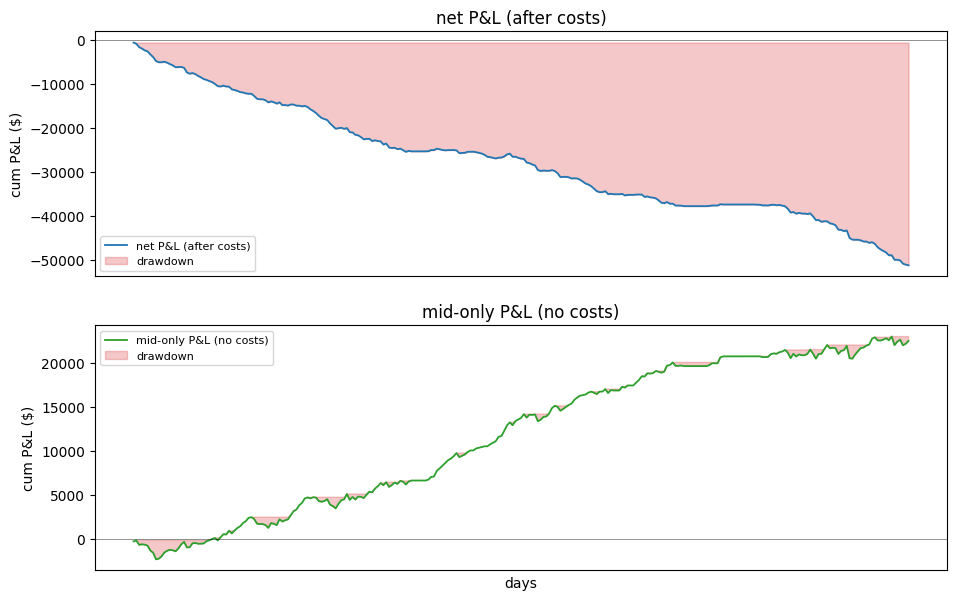

In [6]:
# ---- 7. cumulative P&L across days (net vs mid-only, drawdown shaded) ----
from engine.plots import plot_equity

plot_equity(res)
